In [22]:
import numpy as np
import math 
import matplotlib.pyplot as plt

### Betina

In [23]:
# number of participants
n = 50 

# number of arms/actions
arms = 2

# random number for fake data
rng = np.random.default_rng(0)

# population mean
mu_a = 0

# population variance
tau_a = 1

# true mean reward (using random data) theta[i,a] for participant i and action a
theta = rng.normal(loc=mu_a, scale=tau_a, size=(n, arms))

theta[:5]

array([[ 0.12573022, -0.13210486],
       [ 0.64042265,  0.10490012],
       [-0.53566937,  0.36159505],
       [ 1.30400005,  0.94708096],
       [-0.70373524, -1.26542147]])

In [24]:
# within-person variance
sigma_r = 1 

def get_reward(i, a):
    return rng.normal(loc=theta[i,a], scale=sigma_r)

get_reward(0, 1), get_reward(0, 1), get_reward(0, 1)

(0.3705779865835638, 0.8576081699945031, -0.29639945591659256)

In [25]:
# number of decision times
T = 200

# rate
epsilon = 0

# estimate of arm value
Q = np.zeros((n, arms))

# number of times arm tried
N = np.zeros((n, arms), dtype=int)

actions = np.zeros((n, T), dtype=int)
rewards = np.zeros((n, T))

Greedy bandit learner
- running independently per participant

- each arm for each participant has true mean reward
- learn by averaging 

In [26]:
# RL algorithm

def learning(times, participants, eps, n_arms, seed=0):
    # rng = np.random.default_rng(seed)
    r = rng.normal(loc=theta, scale=sigma_r)
    
    # estimate of arm value
    Q_new = np.zeros((participants, n_arms)) # will explore if reward is negative
    # Q_new = np.full((participants, n_arms), -np.inf)
    # Q_new[:, 0] = 0.0

    # number of times arm tried
    N_new = np.zeros((participants, n_arms), dtype=int)

    actions_new = np.zeros((participants, times), dtype=int)
    rewards_new = np.zeros((participants, times))

    
    for t in range(times):
        for i in range(participants):
            # choose action
        
            if rng.random() < eps: 
                # exploring something new
                a = rng.integers(0, n_arms)
            else: 
                # do what we think is best
                a = int(np.argmax(Q_new[i]))

            # print("WHAT")
            
            r = get_reward(i, a)

            actions_new[i, t] = a
            rewards_new[i, t] = r

            N_new[i, a] += 1
            Q_new[i, a] += (r - Q_new[i, a]) / N_new[i, a]

    return Q_new, N_new, actions_new, rewards_new

Q, N, actions, rewards = learning(T, n, epsilon, arms)


In [27]:
def calculate_diff(a_1, a_2):
    diff = np.zeros((n, arms))
    avg = 0
    
    for i in range(len(a_1)):
        for j in range(len(a_1[0])):
            d = abs(a_2[i, j] - a_1[i, j])
            diff[i, j] = d
            avg += d

    avg = avg / (len(a_1) * len(a_1[0]))

    return diff, avg

In [28]:
# testing different epsilons! 
epsilons = [0, 0.1, 0.5, 1]

def test_epsilons(e):
    for ep in e:
        Q, N, actions, rewards = learning(T, n, ep, arms)
        print(np.bincount(actions.flatten(), minlength=2))
        print(theta[:5])
        print(Q[:5])
        print()
        dif, av = calculate_diff(theta, Q)
        print(av)
        print()
        

test_epsilons(epsilons)

[5412 4588]
[[ 0.12573022 -0.13210486]
 [ 0.64042265  0.10490012]
 [-0.53566937  0.36159505]
 [ 1.30400005  0.94708096]
 [-0.70373524 -1.26542147]]
[[-1.33765558 -0.14684876]
 [ 0.65329253 -1.18223013]
 [-0.28765339  0.27759438]
 [ 1.43625099  0.        ]
 [-1.78025741 -1.25780599]]

0.46159766592242835

[4178 5822]
[[ 0.12573022 -0.13210486]
 [ 0.64042265  0.10490012]
 [-0.53566937  0.36159505]
 [ 1.30400005  0.94708096]
 [-0.70373524 -1.26542147]]
[[-0.52528503 -0.14141807]
 [ 0.65692715  0.08524154]
 [-0.33727434  0.36314413]
 [ 1.34057942  0.83679221]
 [-0.65841583 -0.93270124]]

0.14701938603159714

[4761 5239]
[[ 0.12573022 -0.13210486]
 [ 0.64042265  0.10490012]
 [-0.53566937  0.36159505]
 [ 1.30400005  0.94708096]
 [-0.70373524 -1.26542147]]
[[-0.04963434 -0.04505904]
 [ 0.62399294  0.44409248]
 [-0.65953085  0.48148755]
 [ 1.27662869  0.96627691]
 [-0.75343636 -1.26347092]]

0.08958588746760202

[4998 5002]
[[ 0.12573022 -0.13210486]
 [ 0.64042265  0.10490012]
 [-0.53566937  0

In [29]:
# np.bincount(actions.flatten(), minlength=2)

In [30]:
# theta[:5], Q[:5]

In [31]:
def get_reward_ts(theta, i, a, sigma_r, rng):
    return rng.normal(loc=theta[i, a], scale=sigma_r)

Thompson Sampling
- keeps posterior distribution over each arm's true mean
- samples over arms from the posteriror and chooses arm with highest sampled value
- updates posterior using the reward observed

- note this loops through people one at a time 

In [32]:
def thompson_sampling(times, participants, n_arms, theta, sigma_r, mu0 = 0, tau0 = 1, seed = 0):
    rng = np.random.default_rng(seed)

    # number of times person i tried arm a
    N = np.zeros((participants, n_arms), dtype=int)

    # sum of rewards for specific arm
    S = np.zeros((participants, n_arms), dtype=float)
    
    actions = np.zeros((participants, times), dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    for t in range(times):
        for i in range(participants):
            # posterior information per arm and person
            
            post_mean = np.zeros(n_arms, dtype=float)
            post_var  = np.zeros(n_arms, dtype=float)

            for a in range(n_arms):
                if N[i, a] == 0: # 0 arms checked
                    # No data yet . posterior = prior
                    post_mean[a] = mu0
                    post_var[a]  = tau0**2
                else:
                    # have data so do normal-normal conjugacy to update
                    precision_data  = N[i, a] / (sigma_r**2)
                    precision_prior = 1.0 / (tau0**2)

                    post_var[a]  = 1.0 / (precision_data + precision_prior)
                    post_mean[a] = post_var[a] * (mu0/(tau0**2) + S[i,a]/(sigma_r**2))

            # Thompson step: sample a plausible true mean for each arm
            # so arms with higher variation MIGHT get pickes - HERE IS EXPLORATION
            # uncertain arms explore more and certain arms explored less 
            sampled = rng.normal(loc=post_mean, scale=np.sqrt(post_var))

            # choose arm that is best 
            a_star = int(np.argmax(sampled))

            r = get_reward_ts(theta, i, a_star, sigma_r, rng)

            actions[i, t] = a_star
            rewards[i, t] = r

            N[i, a_star] += 1
            S[i, a_star] += r

    return N, S, actions, rewards
            

In [33]:
# testing
n = 50
arms = 2
T = 200
sigma_r = 1.0

rng0 = np.random.default_rng(42)
theta = rng0.normal(loc=0.0, scale=1.0, size=(n, arms))

N_ts, S_ts, actions_ts, rewards_ts = thompson_sampling(
    times=T, participants=n, n_arms=arms,
    theta=theta, sigma_r=sigma_r,
    mu0=0.0, tau0=1.0, seed=123
)

print("Action counts:", np.bincount(actions_ts.flatten(), minlength=arms))
print("First 5 participants theta:\n", theta[:5])
print("First 5 participants arm counts N:\n", N_ts[:5])


Action counts: [5077 4923]
First 5 participants theta:
 [[ 0.30471708 -1.03998411]
 [ 0.7504512   0.94056472]
 [-1.95103519 -1.30217951]
 [ 0.1278404  -0.31624259]
 [-0.01680116 -0.85304393]]
First 5 participants arm counts N:
 [[195   5]
 [ 38 162]
 [ 23 177]
 [193   7]
 [189  11]]


In [34]:
# regreat = reward obtained by model - ACTUAL best reward (true mean)
def total_expected_regret(theta, acts):
    best = theta.max(axis=1, keepdims=True)  # (n,1)
    chosen = theta[np.arange(theta.shape[0])[:, None], acts]  # (n,T)
    return (best - chosen).sum()

print("T = ", 200)
print("Total expected regret Thompson Sampling:", total_expected_regret(theta, actions_ts))
print("Total expected regret greedy:", total_expected_regret(theta, actions))



T =  200
Total expected regret Thompson Sampling: 395.26716885270775
Total expected regret greedy: 3150.802529780256


### Nora

Function for setting environment

In [35]:
def set_environment(n_new, arms_new, mu_new, tau_new, env_seed=0):
    global n, arms, mu_a, tau_a, rng, theta
    n = int(n_new)
    arms = int(arms_new)
    mu_a = float(mu_new)
    tau_a = float(tau_new)
    rng = np.random.default_rng(env_seed)
    theta = rng.normal(loc=mu_a, scale=tau_a, size=(n, arms))

Empirical Bayes
1. Simple Bayesian learning algorithm
2. Empirical Bayes decision-making

In [36]:
def learning_empirical_bayes(times, participants, n_arms, mu0=0.0, tau0=1.0, seed=0):
    rng = np.random.default_rng(seed)
    sigma2 = float(sigma_r) ** 2

    # these are our priors 
    m = np.full((participants, n_arms), float(mu0))
    v = np.full((participants, n_arms), float(tau0) ** 2)

    N = np.zeros((participants, n_arms), dtype=int)
    actions = np.zeros((participants, times), dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    def normal_cdf(z):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

    # the two functions below fit the hierarchical model based on learning algorithm's outputs 
    def profile_ll_and_mu(x, s2, tau2):
        w = 1.0 / (s2 + tau2)
        mu = np.sum(w * x) / np.sum(w)
        ll = -0.5 * np.sum(np.log(s2 + tau2) + (x - mu) ** 2 * w)
        return ll, mu

    def fit_mu_tau2(x, s2):
        x = np.asarray(x, dtype=float)
        s2 = np.asarray(s2, dtype=float)

        base = float(np.var(x)) + float(np.mean(s2))
        hi = max(1e-6, 10.0 * base)
        grid = np.logspace(-8, np.log10(hi), 120)

        best_tau2 = 0.0
        best_ll, best_mu = profile_ll_and_mu(x, s2, 0.0)

        for tau2 in grid:
            ll, mu = profile_ll_and_mu(x, s2, float(tau2))
            if ll > best_ll:
                best_ll, best_mu, best_tau2 = ll, mu, float(tau2)

        return best_mu, best_tau2

    # okay let's loop through all the decision times using the functions we defined above to do EB
    for t in range(times):
        # these are the *hyper*parameters aka population-level parameters
        mu_hat = np.zeros(n_arms, dtype=float)
        tau2_hat = np.zeros(n_arms, dtype=float)

        for a in range(n_arms):
            mu_hat[a], tau2_hat[a] = fit_mu_tau2(m[:, a], v[:, a])

        # these are the *person*-level parameters
        m_eb = np.zeros_like(m, dtype=float)
        v_eb = np.zeros_like(v, dtype=float)

        # let's compute the posteriors .....
        for a in range(n_arms):
            if tau2_hat[a] <= 0.0:
                m_eb[:, a] = mu_hat[a]
                v_eb[:, a] = 0.0
            else:
                lam = tau2_hat[a] / (tau2_hat[a] + v[:, a])
                m_eb[:, a] = lam * m[:, a] + (1.0 - lam) * mu_hat[a]
                v_eb[:, a] = 1.0 / (1.0 / v[:, a] + 1.0 / tau2_hat[a])

        # now using the posteriors we can determine distribution of difference between the two arms & based on that we select an action!
        for i in range(participants):
            if n_arms == 2:
                m_diff = m_eb[i, 1] - m_eb[i, 0]
                v_diff = v_eb[i, 1] + v_eb[i, 0]
                if v_diff <= 0.0:
                    a = 1 if m_diff > 0.0 else 0
                else:
                    p1 = normal_cdf(m_diff / math.sqrt(v_diff))
                    a = 1 if rng.random() < p1 else 0
            else:
                sample = rng.normal(loc=m_eb[i], scale=np.sqrt(np.maximum(v_eb[i], 0.0)))
                a = int(np.argmax(sample))

            # reward time! yay! let's see what reward we get based on the action...
            r = get_reward(i, a)

            actions[i, t] = a
            rewards[i, t] = r
            N[i, a] += 1

            # okay time to learn from the reward
            prec = 1.0 / v[i, a] + 1.0 / sigma2
            v_new = 1.0 / prec
            m_new = v_new * (m[i, a] / v[i, a] + r / sigma2)

            m[i, a] = m_new
            v[i, a] = v_new

    return m, v, N, actions, rewards

Comparison between empirical Bayes, greedy bandit learner, and Thompson sampling 

In [39]:
def cumulative_regret(theta, actions):
    n, T = actions.shape
    best = theta.max(axis=1, keepdims=True)
    chosen = theta[np.arange(n)[:, None], actions]
    inst = best - chosen
    return np.cumsum(inst.mean(axis=0))

def evaluate(seed=123, eps=None, mu0=0.0, tau0=1.0):
    if eps is None:
        eps = epsilon

    Q_g, N_g, actions_g, rewards_g = learning(T, n, eps, arms)

    N_ts, S_ts, actions_ts, rewards_ts = thompson_sampling(
        T, n, arms, theta, sigma_r, mu0=mu0, tau0=tau0, seed=seed
    )

    m_eb, v_eb, N_eb, actions_eb, rewards_eb = learning_empirical_bayes(
        T, n, arms, mu0=mu0, tau0=tau0, seed=seed
    )

    reg_g  = cumulative_regret(theta, actions_g)
    reg_ts = cumulative_regret(theta, actions_ts)
    reg_eb = cumulative_regret(theta, actions_eb)

    return {
        "actions_greedy": actions_g,
        "actions_thompson": actions_ts,
        "actions_eb": actions_eb,
        "regret_greedy": reg_g,
        "regret_thompson": reg_ts,
        "regret_eb": reg_eb,
        "N_ts": N_ts,
        "S_ts": S_ts,
        "rewards_ts": rewards_ts,
        "rewards_eb": rewards_eb,
        "rewards_greedy": rewards_g,
    }

In [52]:
def plot(ns, mus, taus, env_seed=0, alg_seed=8, eps=None, mu0=0.0, tau0=1.0):
    if eps is None:
        eps = epsilon

    PASTEL = {"greedy": "#A1C9F4", "thompson": "#FFB482", "eb": "#8DE5A1"}

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                set_environment(n_val, arms, mu_val, tau_val, env_seed=env_seed)
                out = evaluate(seed=alg_seed, eps=eps, mu0=mu0, tau0=tau0)

                ax = axs[i, j]
                ax.plot(out["regret_greedy"],  color=PASTEL["greedy"],   linewidth=1.4)
                ax.plot(out["regret_thompson"], color=PASTEL["thompson"], linewidth=1.4)
                ax.plot(out["regret_eb"],      color=PASTEL["eb"],       linewidth=1.4)

                ax.set_title(f"μ={mu_val}, τ={tau_val}", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)

                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)
        
        handles, labels = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, ["Greedy", "Thompson", "EB"], loc="upper right", fontsize=8)
        fig.suptitle(f"n = {n_val}", fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()

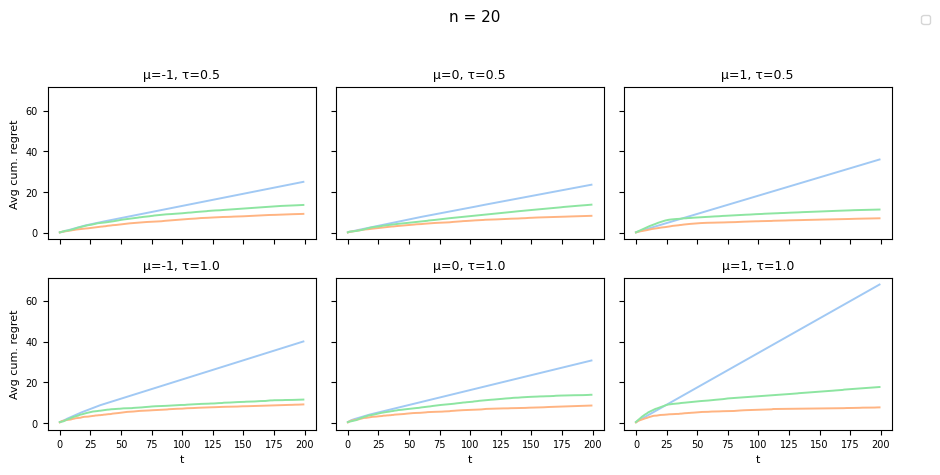

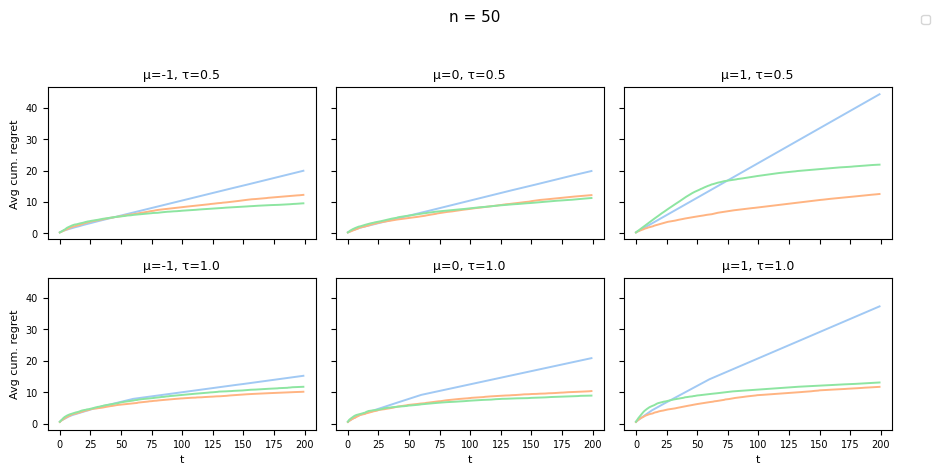

In [53]:
ns = [20, 50]
mus = [-1, 0, 1]
taus = [0.5, 1.0]

plot(ns, mus, taus)

**LEGEND**

greedy = blue
thompson = orange
empirical bayes = green